In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
!ln -s /content/drive/MyDrive/Colab\ Notebooks/SES-Inference /mydrive

Mounted at /content/drive


In [2]:
import os
import sys
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append('/mydrive/libs/')
%set_env PYTHONPATH=/env/python:/mydrive/libs/

%load_ext autoreload
%autoreload 2

from utils import ios
from utils import viz

env: PYTHONPATH=/env/python:/mydrive/libs/


# Functions

In [3]:
### UTILS
def get_file(path, postfix):
  path = os.path.join(path,"*{}".format(postfix))
  files = [fn for fn in glob.glob(path)]
  if len(files) == 1:
    return ios.load_csv(files[0], index_col=0)
  return None

def get_survey(path):
  return get_file(path, "_iwi_cluster.csv")

def get_population(path):
  return get_file(path, "_population.csv")
  
def get_nightlights(path):
  return get_file(path, "_NTLL.csv")

def get_marketng(path):
  return get_file(path, "_FBM.csv")

### POPULATION
def plot_population_distributions(df, logcounts=(False,False), logpdf=(False,False)):
  # raw, counts, pdf, cdf

  fig,axes = plt.subplots(1,4, figsize=(14,3), sharex=False, sharey=False)

  _ = df.distance_closest_tile.plot(ax=axes[0])
  axes[0].set_xlabel("cluster_id")
  axes[0].set_title("Distance (meters)")

  _ = sns.histplot(df, x='distance_closest_tile', stat='count', ax=axes[1], log_scale=logcounts)
  axes[1].set_title("Counts")
  axes[1].set_ylabel("")

  _ = sns.kdeplot(data=df, x='distance_closest_tile', ax=axes[2], log_scale=logpdf)
  axes[2].set_title("PDF")
  axes[2].set_ylabel("")

  _ = sns.ecdfplot(df, x='distance_closest_tile', stat='proportion', ax=axes[3])
  axes[3].set_title("CDF")
  axes[3].set_ylabel("")

  fig.tight_layout(rect=[0, 0.03, 1, 0.95])
  plt.show()
  plt.close()

from sklearn.preprocessing import normalize
from sklearn.preprocessing import MinMaxScaler

def plot_NTLL_distribution(df_survey, df_ntll, country, kind='ecdf', norm=False):
  if kind not in ['ecdf','kde','hist']:
   raise Exception("normalization function does not exist.")
  
  stats = ['min','mean','median','max']
  radiuses = [1.6, 2.0, 5.0, 10.0]

  for c, radius in enumerate(radiuses):
    tmp = df_survey[['DHSYEAR']]
    data = tmp.join(df_ntll[[c for c in df_ntll.columns if '{}km_min'.format(radius) in c or '{}km_max'.format(radius) in c or '{}km_mean'.format(radius) in c or '{}km_median'.format(radius) in c]])
    data = get_normed_data(data, norm)
    data.loc[:,'DHSYEAR'] = tmp
    data = data.melt(id_vars='DHSYEAR', var_name='stat', value_name='radiance')
    fg = sns.displot(data=data, x="radiance", col='stat', hue='DHSYEAR', kind=kind, height=2.5, aspect=1, facet_kws={'sharex': False, 'sharey': False}, palette="tab10")

def get_normed_data(data, norm):
  if norm == 'mean0':
    return data.groupby('DHSYEAR').transform(lambda x: (x - x.mean()) / x.std())
  if norm == 'max':
    return data.groupby('DHSYEAR').transform(lambda x: x / x.max())
  if norm == 'minmax':
    return data.groupby('DHSYEAR').transform(lambda x: (x - x.min()) / (x.max()-x.min()))

# Country

In [26]:
country = 'Uganda'
# country = 'Sierra Leone'
path = '/mydrive/data/{}/results'.format(country)

## Survey

In [27]:
df_dhs = get_survey(path)
df_dhs.head()

,DHSCC,DHSYEAR,DHSCLUST,URBAN_RURA,LATNUM,LONGNUM,SOURCE,ALT_GPS,ALT_DEM,DATUM,mean_iwi,SES
0,UG,2016,1,1,0.320188,32.568206,GPS,9999.0,1197.0,WGS84,43.300000,rich
1,UG,2016,2,1,0.340653,32.593627,GPS,9999.0,1179.0,WGS84,24.967857,rich
2,UG,2016,3,1,0.313103,32.566556,GPS,9999.0,1189.0,WGS84,34.732000,rich
3,UG,2016,4,1,0.353368,32.558144,GPS,9999.0,1181.0,WGS84,36.060714,rich
4,UG,2016,5,1,0.367388,32.594357,GPS,9999.0,1226.0,WGS84,44.857692,rich


## Facebook Population

In [28]:
df_pop = get_population(path)
df_pop.head()

,distance_closest_tile,population_closest_tile,population_in_1.6km,population_in_2.0km,population_in_5.0km,population_in_10.0km
0,43.570147,14.780448,22366.634497,37133.430237,266328.392079,1.180737e+06
1,27.958416,14.780448,19577.204413,33030.175271,238955.658769,1.025650e+06
2,25.764101,14.780448,24388.507572,37241.554805,261012.279742,1.153742e+06
3,29.287408,33.087972,47960.786056,71201.123993,392824.810726,1.124804e+06
4,26.120940,33.087972,27290.527148,40174.711688,255762.523401,9.102187e+05


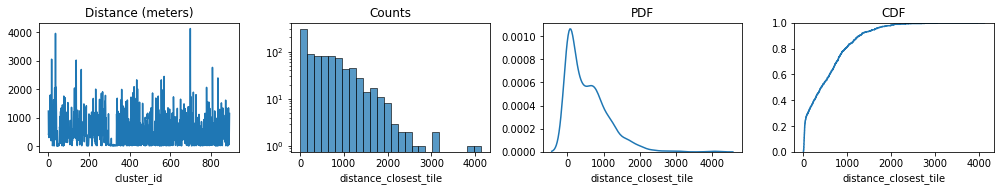

In [11]:
plot_population_distributions(df_pop, logcounts=(False,True), logpdf=(False,False))

## VIIRS Nightlights

In [12]:
df_ntll = get_nightlights(path)
df_ntll.head()

,NTLL_1.6km_min,NTLL_1.6km_max,NTLL_1.6km_mean,NTLL_1.6km_median,NTLL_1.6km_l3_mean,NTLL_1.6km_u3_mean,NTLL_1.6km_rad_gte_10.0_area,NTLL_1.6km_rad_gte_10.0_pixels,NTLL_1.6km_rad_gte_10.0_sum_rad,NTLL_2.0km_min,NTLL_2.0km_max,NTLL_2.0km_mean,NTLL_2.0km_median,NTLL_2.0km_l3_mean,NTLL_2.0km_u3_mean,NTLL_2.0km_rad_gte_10.0_area,NTLL_2.0km_rad_gte_10.0_pixels,NTLL_2.0km_rad_gte_10.0_sum_rad,NTLL_5.0km_min,NTLL_5.0km_max,NTLL_5.0km_mean,NTLL_5.0km_median,NTLL_5.0km_l3_mean,NTLL_5.0km_u3_mean,NTLL_5.0km_rad_gte_10.0_area,NTLL_5.0km_rad_gte_10.0_pixels,NTLL_5.0km_rad_gte_10.0_sum_rad,NTLL_10.0km_min,NTLL_10.0km_max,NTLL_10.0km_mean,NTLL_10.0km_median,NTLL_10.0km_l3_mean,NTLL_10.0km_u3_mean,NTLL_10.0km_rad_gte_10.0_area,NTLL_10.0km_rad_gte_10.0_pixels,NTLL_10.0km_rad_gte_10.0_sum_rad
0,0.000208,0.068138,0.032545,0.033994,0.017199,0.047006,0.0,0.0,0.0,0.000208,0.068138,0.033028,0.034290,0.017598,0.047356,0.0,0.0,0.0,0.000208,0.113204,0.041247,0.040747,0.024590,0.058352,0.0,0.0,0.0,-0.000350,0.126951,0.045743,0.044402,0.027722,0.065023,0.0,0.0,0.0
1,0.028221,0.103269,0.066592,0.067560,0.048828,0.082564,0.0,0.0,0.0,0.028221,0.103269,0.064956,0.065289,0.047557,0.081355,0.0,0.0,0.0,0.014179,0.109191,0.062550,0.062895,0.045498,0.079465,0.0,0.0,0.0,0.009869,0.117903,0.059583,0.058829,0.042164,0.077411,0.0,0.0,0.0
2,0.025167,0.112642,0.070448,0.068245,0.048377,0.092932,0.0,0.0,0.0,0.025167,0.112642,0.068997,0.068245,0.048117,0.089669,0.0,0.0,0.0,0.012597,0.113296,0.065023,0.065180,0.045601,0.084145,0.0,0.0,0.0,-0.001355,0.192999,0.058710,0.059023,0.038895,0.078495,0.0,0.0,0.0
3,0.026151,0.100974,0.063029,0.059750,0.040614,0.085981,0.0,0.0,0.0,0.017220,0.100974,0.059813,0.056869,0.037520,0.083634,0.0,0.0,0.0,-0.004514,1.403334,0.062004,0.051138,0.036411,0.094166,0.0,0.0,0.0,-0.011937,1.403334,0.054513,0.050852,0.032305,0.082148,0.0,0.0,0.0
4,0.018828,0.206288,0.069350,0.066081,0.041539,0.100739,0.0,0.0,0.0,0.018828,0.538011,0.072840,0.064862,0.041092,0.111044,0.0,0.0,0.0,0.010267,5.334144,0.121795,0.047269,0.041759,0.262327,0.0,0.0,0.0,-0.009393,7.040654,0.086018,0.046611,0.037598,0.171263,0.0,0.0,0.0


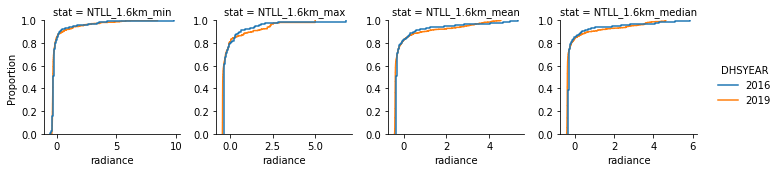

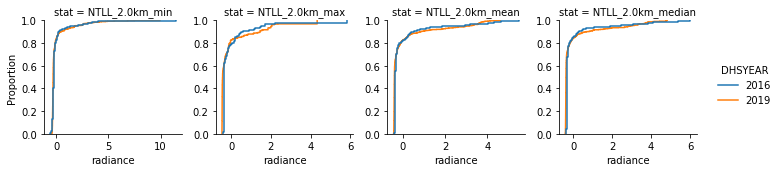

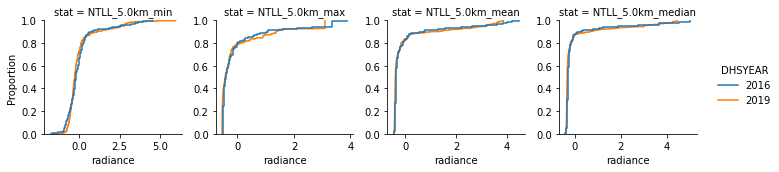

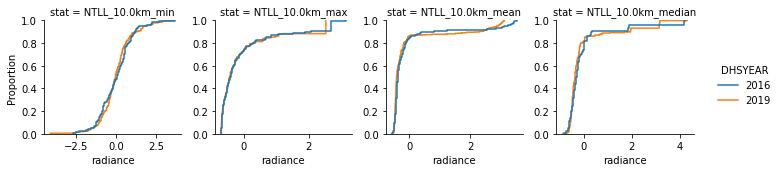

In [13]:
plot_NTLL_distribution(df_dhs, df_ntll, country, kind='ecdf', norm='mean0')

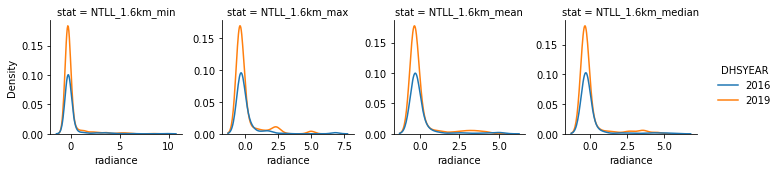

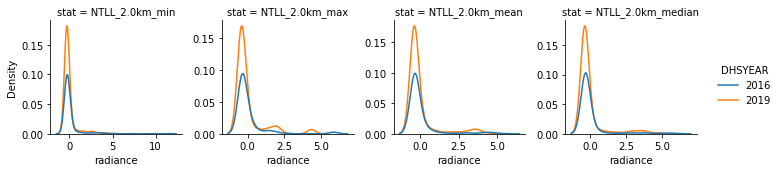

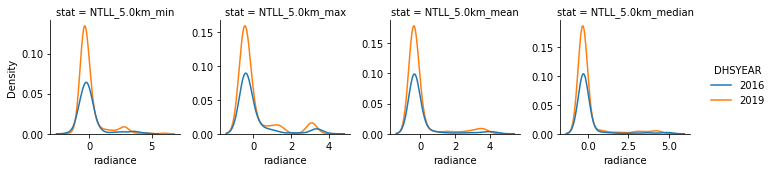

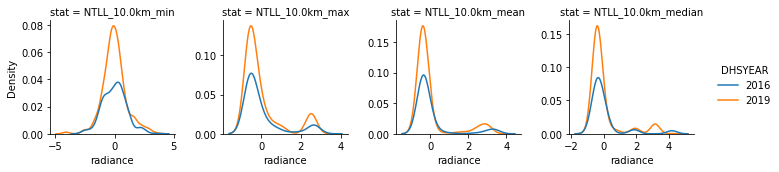

In [14]:
plot_NTLL_distribution(df_dhs, df_ntll, country, kind='kde', norm='mean0')

# Facebook Marketing

In [29]:
df_fbm = get_marketng(path)
df_fbm.head()

,FBM_frequent_traveler,FBM_small_business_owner,FBM_commuter,FBM_lives_abroad,FBM_frequent_int_traveler,FBM_network_2G,FBM_network_3G,FBM_network_4G,FBM_feature_phone,FBM_old_device_os,FBM_mobile_access,FBM_browser_access,FBM_smartphone_tablet,FBM_wifi,FBM_tech_early_adopter,FBM_away_from_home,FBM_ind_gov,FBM_ind_business,FBM_ind_legal,FBM_ind_it,FBM_device_motorola,FBM_device_amazon,FBM_device_nokia,FBM_device_microsoft,FBM_os_ios,FBM_os_android,FBM_os_windows,FBM_os_windows_desktop,FBM_os_windows_phone,FBM_highschool,FBM_bachelor,FBM_master,FBM_professional,FBM_phd
0,66000.0,7400.0,1000.0,6600.0,66000.0,1000.0,37000.0,15000.0,1000.0,19000.0,30000.0,8700.0,63000.0,6100.0,2900.0,4400.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,2800.0,1000.0,6800.0,110000.0,1500.0,1500.0,1000.0,14000.0,3700.0,40000.0,1000.0,1000.0
1,68000.0,7400.0,1000.0,6800.0,68000.0,1000.0,38000.0,15000.0,1000.0,19000.0,31000.0,9000.0,65000.0,6100.0,2900.0,4700.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,2700.0,1000.0,7200.0,110000.0,1400.0,1400.0,1000.0,14000.0,3600.0,40000.0,1000.0,1000.0
2,75000.0,8200.0,1000.0,7300.0,74000.0,1000.0,41000.0,17000.0,1000.0,21000.0,33000.0,9700.0,71000.0,6900.0,3300.0,5000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,3100.0,1000.0,7600.0,120000.0,1600.0,1600.0,1000.0,16000.0,4000.0,45000.0,1000.0,1000.0
3,42000.0,4500.0,1000.0,4100.0,42000.0,1000.0,23000.0,9600.0,1000.0,12000.0,19000.0,5500.0,40000.0,3800.0,1800.0,2900.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1700.0,1000.0,4500.0,67000.0,1000.0,1000.0,1000.0,8800.0,2300.0,25000.0,1000.0,1000.0
4,580000.0,72000.0,31000.0,68000.0,580000.0,5600.0,270000.0,170000.0,6700.0,180000.0,290000.0,88000.0,580000.0,75000.0,31000.0,55000.0,1000.0,5500.0,1000.0,7000.0,3100.0,1000.0,26000.0,1000.0,54000.0,890000.0,16000.0,16000.0,1000.0,120000.0,44000.0,390000.0,1000.0,1000.0


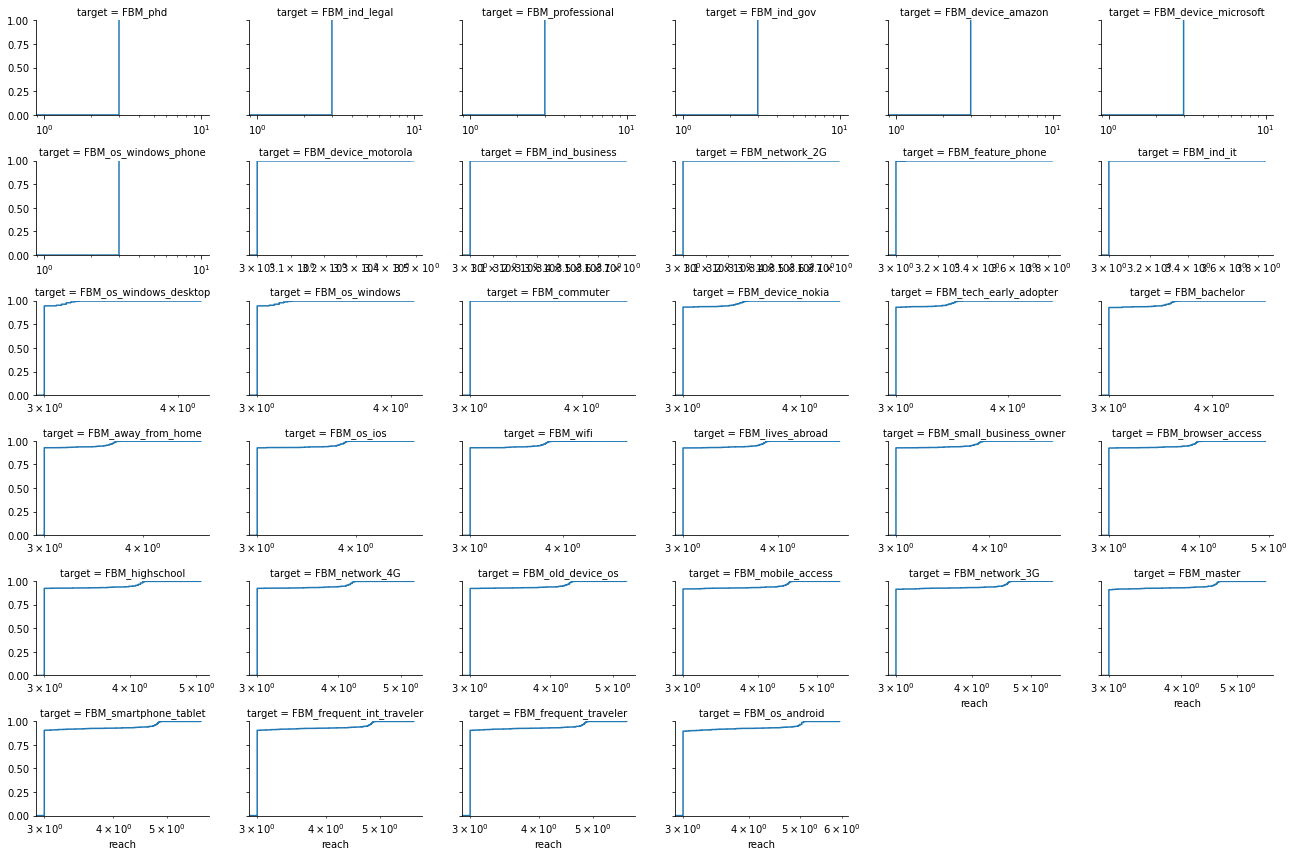

In [30]:
data = df_fbm.melt(var_name='target', value_name='reach')
ranking = data.groupby('target').reach.sum().sort_values().index.values
data['ctarget'] = pd.Categorical(data['target'], ranking)

fg = sns.FacetGrid(data=data.sort_values('ctarget'), col='target', col_wrap=6, height=2, aspect=1.5, sharex=False, dropna=True)
fg.map(sns.ecdfplot, 'reach', log_scale=True)

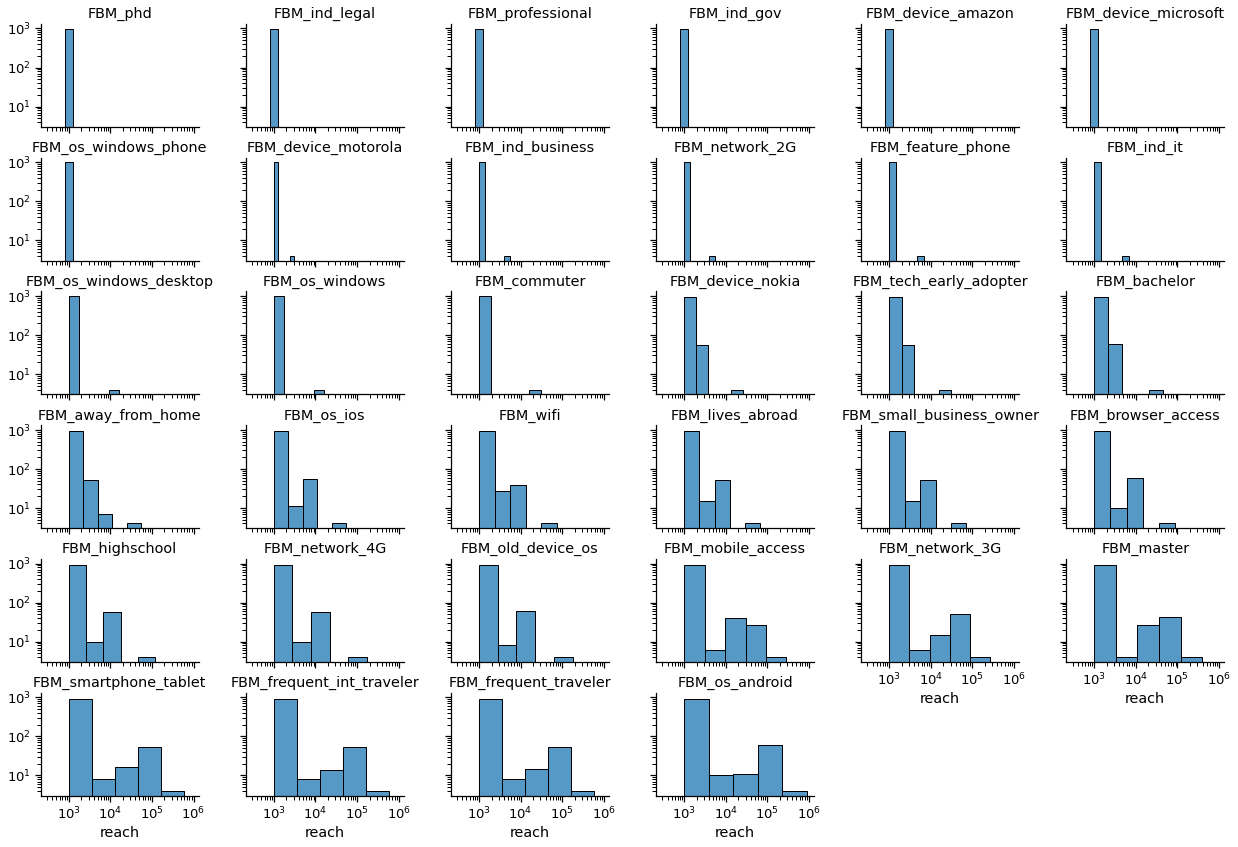

In [31]:
with sns.plotting_context("notebook", font_scale=1.2):
  df_melt = df_fbm.melt(var_name='target', value_name='reach')
  rank = df_melt.groupby('target').reach.sum().sort_values()
  ranking_num_people = rank.values
  ranking_labels = rank.index.values
  fg = sns.FacetGrid(data=df_melt, col='target', col_wrap=6, col_order=ranking_labels, height=2, aspect=1.5)
  fg.map(sns.histplot, 'reach', bins=5, log_scale=(True,True))
  fg.set_titles(col_template = '{col_name}')
  plt.subplots_adjust(wspace=0.3, hspace=0.3)

In [18]:
df_fbm.isna().sum()

FBM_frequent_traveler        0
FBM_small_business_owner     0
FBM_commuter                 0
FBM_lives_abroad             0
FBM_frequent_int_traveler    0
FBM_network_2G               0
FBM_network_3G               0
FBM_network_4G               0
FBM_feature_phone            0
FBM_old_device_os            0
FBM_mobile_access            0
FBM_browser_access           0
FBM_smartphone_tablet        0
FBM_wifi                     0
FBM_tech_early_adopter       0
FBM_away_from_home           0
FBM_ind_gov                  0
FBM_ind_business             0
FBM_ind_legal                0
FBM_ind_it                   0
FBM_device_motorola          0
FBM_device_amazon            0
FBM_device_nokia             0
FBM_device_microsoft         0
FBM_os_ios                   0
FBM_os_android               0
FBM_os_windows               0
FBM_os_windows_desktop       0
FBM_os_windows_phone         0
FBM_highschool               0
FBM_bachelor                 0
FBM_master                   0
FBM_prof

# Intersection 
Run twice

In [52]:
### SL:
# ranking_labels_SL = ranking_labels.copy()           # Label position (index)
# ranking_num_people_SL = ranking_num_people.copy()   # Number of people (values)

### UG:
# ranking_labels_UG = ranking_labels.copy()
# ranking_num_people_UG = ranking_num_people.copy()

### MERGE
df_UG = pd.DataFrame({'reachUG':ranking_num_people_UG}, index=ranking_labels_UG)
df_SL = pd.DataFrame({'reachSL':ranking_num_people_SL}, index=ranking_labels_SL)
df_rank = pd.concat([df_UG, df_SL], axis=1)
df_rank

,reachUG,reachSL
FBM_phd,991000.0,893000.0
FBM_ind_legal,991000.0,893000.0
FBM_professional,991000.0,893000.0
FBM_ind_gov,991000.0,893000.0
FBM_device_amazon,991000.0,893000.0
FBM_device_microsoft,991000.0,893000.0
FBM_os_windows_phone,991000.0,893000.0
FBM_device_motorola,999200.0,917600.0
FBM_ind_business,1009100.0,893000.0
FBM_network_2G,1009200.0,1094100.0


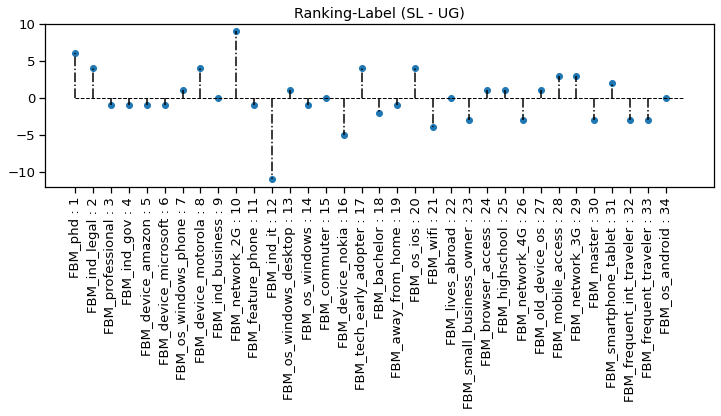

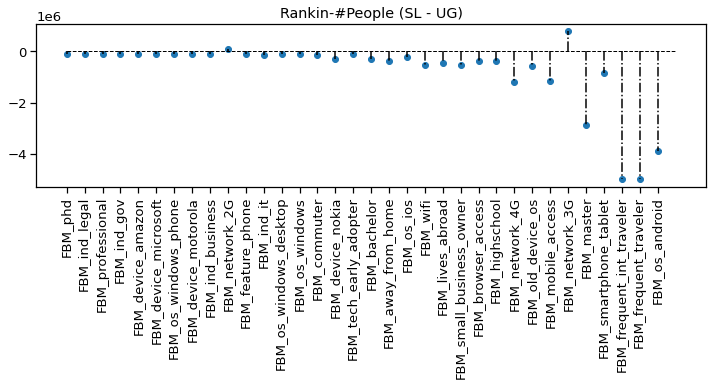

In [51]:
import numpy as np

for label in ['Ranking-Label','Rankin-#People']:
  with sns.plotting_context("notebook", font_scale=1.2):
    plt.rcParams["figure.figsize"] = (12,3)

    if 'Label' in label:
      Y = np.array([np.where(ranking_labels_SL==rug)[0][0]-iug for iug,rug in enumerate(ranking_labels_UG)])
      Xlabels = ["{} : {}".format(r,i+1) for i, r in enumerate(ranking_labels_UG)]
    else:
      Y = [df_rank.loc[id,'reachSL']-df_rank.loc[id,'reachUG'] for id in ranking_labels_UG]
      Xlabels = ranking_labels_UG

    X = np.arange(len(Xlabels))
    _=plt.scatter(X,Y)
    _=plt.plot((X,X),([0 for i in Y], [j for j in Y]),c='k',ls='-.') #,c='black')
    _=plt.plot([0,34],[0,0],lw=1.0,ls='--',c='k')
    _=plt.title("{} (SL - UG)".format(label))
    _=plt.xticks(X, Xlabels, rotation=90)
    plt.show()
    plt.close()

In [ ]:
intersection = np.intersect1d(ranking_SL[:12], ranking_UG[:12])
intersection.shape

(11,)

In [ ]:
# in top 12 SLE but not in intersection
[rsl for rsl in ranking_SL[:12] if rsl not in intersection]

['FBM_device_nokia']

In [ ]:
# in top 12 UG but not in intersection
[rsl for rsl in ranking_UG[:12] if rsl not in intersection]

['FBM_network_2G']

## Old code

In [ ]:
### OLD CODE

# def plot_population_distribution(df, nbins=3):

#   # raw values
#   fig,ax = plt.subplots(1,1,figsize=(6,4))
#   _ = df.population_closest_tile.plot(ax=ax)
#   ax.set_title("Distance to closest tile")
#   ax.set_ylabel("distance (meters)")
#   ax.set_xlabel("cluster id")
#   plt.show()
#   plt.close()

#   # distribution
#   viz.plot_distribution(df, 'distance_closest_tile', nbins=nbins)

#    # distribution
#   viz.plot_distribution(df, 'distance_closest_tile', quantiles=True, nbins=nbins)


### NIGHTLIGHTS
# def compare_ntll_by_year(df_survey, df_ntll, country, norm):

#   if norm not in [None,'max','sum']:
#     raise Exception("normalization function does not exist.")

#   radiuses = [1.6, 2.0, 5.0, 10.0]
#   fig,axes = plt.subplots(1, len(radiuses), figsize=(len(radiuses)*6,3), sharex=True, sharey=True)

#   for i, radius in enumerate(radiuses):
#     data = df_survey[['DHSYEAR']].join(df_ntll[[c for c in df_ntll.columns if '{}km_min'.format(radius) in c or '{}km_max'.format(radius) in c or '{}km_mean'.format(radius) in c or '{}km_median'.format(radius) in c]])
#     years = data.DHSYEAR.unique()
    
#     if norm is not None:
#       for c in data.columns:
#         if c == 'DHSYEAR':
#           continue
#         data[c] = data[c] / data.groupby('DHSYEAR')[c.replace("_min","_max").replace("_mean","_max").replace("_median","_max")].transform(norm)

#     gb = data.groupby('DHSYEAR')
#     minimum = gb.min()['NTLL_{}km_min'.format(radius)].values
#     maximum = gb.max()['NTLL_{}km_max'.format(radius)].values
#     min_mean = gb.min()['NTLL_{}km_mean'.format(radius)].values
#     min_median = gb.min()['NTLL_{}km_median'.format(radius)].values
#     max_mean = gb.max()['NTLL_{}km_mean'.format(radius)].values
#     max_median = gb.max()['NTLL_{}km_median'.format(radius)].values
#     groups = {'min(min)':minimum, 'max(max)':maximum, 'min(mean)':min_mean, 'max(mean)':max_mean, 'min(median)':min_median, 'max(median)':max_median}

#     # Convert data to pandas DataFrame.
#     df = pd.DataFrame(groups, index=years).T

#     # Plot.
#     ax = axes[i]
#     df.plot.bar(rot=0, ax=ax, legend=False)
#     ax.set_title("Buffer within {}Km".format(radius))
#     # if norm is None:
#     #   ax.set_yscale('symlog')

#   axes[0].set_ylabel("radiance")
#   plt.suptitle("Aggregated statistics{}\n{}".format('' if norm is None else " (norm={})".format(norm), country))
#   plt.legend(loc='best')
#   fig.tight_layout(rect=[0, 0.03, 1, 0.95])
#   return data


In [ ]:
data = df_fbm.melt(var_name='target', value_name='reach')
ranking = data.groupby('target').reach.sum().sort_values().index.values
data['ctarget'] = pd.Categorical(data['target'], ranking)

fg = sns.FacetGrid(data=data.sort_values('ctarget'), col='target', col_wrap=6, height=2, aspect=1.5, sharex=False, dropna=True)
fg.map(sns.ecdfplot, 'reach', log_scale=True)


In [ ]:
df_iwi_fbm = df_dhs[['mean_iwi']].join(df_fbm)
df_iwi_fbm = df_iwi_fbm.melt(id_vars='mean_iwi', var_name='target', value_name='reach')
fg = sns.FacetGrid(data=df_iwi_fbm, col='target', col_wrap=6, height=2, aspect=1.5, sharex=False, dropna=True)
fg.map(sns.histplot, 'reach', 'mean_iwi', bins=100, cbar=True)

In [ ]:
ranking = df_iwi_fbm.groupby('target').reach.sum().sort_values().index.values
for c in ranking:
  g = sns.JointGrid(data=df_iwi_fbm.query("target==@c"), x="reach", y="mean_iwi", marginal_ticks=True, height=4)

  # Set a log scaling on the y axis
  g.ax_joint.set(xscale="log")
  g.fig.suptitle(c)

  # Create an inset legend for the histogram colorbar
  cax = g.fig.add_axes([1, .55, .02, .2])

  # Add the joint and marginal histogram plots
  g.plot_joint(
      sns.histplot, discrete=(True, False),
      cmap="light:#03012d", pmax=.8, cbar=True, cbar_ax=cax
  )
  g.plot_marginals(sns.histplot, element="step", color="#03012d", )
  plt.show()
  plt.close()

In [ ]:
df_melt = df_fbm.melt(var_name='target', value_name='reach')
ranking = df_melt.groupby('target').reach.sum().sort_values().index.values
for c in ranking:
  sns.displot(data=df_fbm, x=c, bins=10, log_scale=(True,True), height=3)
  plt.show()
  plt.close()